<a href="https://colab.research.google.com/github/kopylch/Data_Analysis_Cafesales/blob/main/DATA_ANALYSIS_ASSIGNMENT_cafesales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('seaborn-v0_8-pastel')
sns.set_palette("pastel")

In [43]:
dataframe = pd.read_csv('assignment_cafesales.csv')
dataframe

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [ ]:
print(dataframe.isnull().sum())

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


In [ ]:
dataframe.info()
dataframe.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [ ]:
price_per_unit = dataframe.groupby('Item')['Price Per Unit'].nunique()
print(price_per_unit)

Item
Cake        3
Coffee      3
Cookie      3
ERROR       8
Juice       3
Salad       3
Sandwich    3
Smoothie    3
Tea         3
UNKNOWN     8
Name: Price Per Unit, dtype: int64


In [ ]:
dataframe.columns	=	dataframe.columns.str.replace(' ',	'_').str.lower()


In [ ]:
dataframe.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


#standarisasi nama column


In [ ]:
dataframe.columns

Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date'],
      dtype='object')

In [ ]:
object_cols = dataframe[['payment_method', 'location', 'item', 'transaction_date']]
placeholders	=	[r'^(UNKNOWN|unknown)$',	r'^(ERROR|error)$',	r'^(-)$']
for	col	in	dataframe.columns:
  for	placeholder	in	placeholders:
    dataframe[col]	=	dataframe[col].replace(placeholder,	np.nan,	regex=True)

print("\nData after replacing placeholders with NaN (example of some columns that might be affected):")
potential_placeholder_cols	=	['item',	'quantity',	'price_per_unit',	'total_spent',	'payment_method',	'location',	'transaction_date']
existing_placeholder_cols	=	[col	for	col	in	potential_placeholder_cols	if	col	in	dataframe.columns]
if	existing_placeholder_cols:
  print(dataframe[existing_placeholder_cols].head())



Data after replacing placeholders with NaN (example of some columns that might be affected):
     item quantity price_per_unit total_spent  payment_method  location  \
0  Coffee        2            2.0         4.0     Credit Card  Takeaway   
1    Cake        4            3.0        12.0            Cash  In-store   
2  Cookie        4            1.0         NaN     Credit Card  In-store   
3   Salad        2            5.0        10.0             NaN       NaN   
4  Coffee        2            2.0         4.0  Digital Wallet  In-store   

  transaction_date  
0       2023-09-08  
1       2023-05-16  
2       2023-07-19  
3       2023-04-27  
4       2023-06-11  


In [ ]:
dataframe.isnull().sum()

,0
transaction_id,0
item,969
quantity,479
price_per_unit,533
total_spent,502
payment_method,3178
location,3961
transaction_date,460


In [ ]:
dataframe['quantity']	=	pd.to_numeric(dataframe['quantity'],	errors='coerce')
dataframe['price_per_unit']	=	pd.to_numeric(dataframe['price_per_unit'],	errors='coerce')
dataframe['total_spent']	=	pd.to_numeric(dataframe['total_spent'],	errors='coerce')
dataframe['transaction_date']	=	pd.to_datetime(dataframe['transaction_date'],	errors='coerce')
print("\nDataFrame information after initial data type correction:")
dataframe.info()


DataFrame information after initial data type correction:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  object        
 1   item              9031 non-null   object        
 2   quantity          9521 non-null   float64       
 3   price_per_unit    9467 non-null   float64       
 4   total_spent       9498 non-null   float64       
 5   payment_method    6822 non-null   object        
 6   location          6039 non-null   object        
 7   transaction_date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 625.1+ KB


In [ ]:
print("\nNumber of missing values ​​after data type conversion (including placeholders converted to NaN/NaT)):")
print(dataframe.isnull().sum())


Number of missing values ​​after data type conversion (including placeholders converted to NaN/NaT)):
transaction_id         0
item                 969
quantity             479
price_per_unit       533
total_spent          502
payment_method      3178
location            3961
transaction_date     460
dtype: int64


In [ ]:
dataframe['calculated_total_spent'] = dataframe['quantity'] * dataframe['price_per_unit']
print("\n'calculated total spent' column has been added.")
print(dataframe[['quantity', 'price_per_unit', 'total_spent', 'calculated_total_spent']].head())

print("\n--- COMPARE 'total_spent' WITH 'calculated_total_spent' BEFORE UPDATE/DROP ---")

mask_comparison = dataframe['total_spent'].notna() & dataframe['calculated_total_spent'].notna()
df_for_comparison = dataframe[mask_comparison].copy() # Use .copy() to avoid warnings
if not df_for_comparison.empty:
    df_for_comparison['fit'] = np.isclose(df_for_comparison['total_spent'], df_for_comparison['calculated_total_spent'])

    amount_can_be_compared = len(df_for_comparison)
    number_of_matches = df_for_comparison['fit'].sum()
    number_mismatch = amount_can_be_compared - number_of_matches

    print(f"Number of rows to compare (both numeric): {amount_can_be_compared}")
    print(f"Number of rows where 'total_spent' MATCHES 'calculated_total_spent': {number_of_matches}")
    print(f"Number of rows where 'total_spent' DOES NOT MATCH 'calculated_total_spent': {number_mismatch}")

    if number_mismatch > 0:
        print("\nExample of a row where 'total_spent' does not match 'calculated_total_spent':")
        display_column = ['quantity', 'price_per_unit', 'total_spent', 'calculated_total_spent']
        if 'transaction_id' in df_for_comparison.columns:
            display_column.insert(0, 'transaction_id')

        print(df_for_comparison[~df_for_comparison['fit']][display_column].head())
else:
    print("There are no rows to compare (e.g., the original 'total_spent' is always NaN or the calculation does not produce a number).")

print("--- END OF COMPARISON ---")


fill_condition = dataframe['total_spent'].isnull() & dataframe['calculated_total_spent'].notnull()
dataframe.loc[fill_condition, 'total_spent'] = dataframe.loc[fill_condition, 'calculated_total_spent']
print(f"\n{fill_condition.sum()} NaN values ​​in 'total_spent' are filled using quantity * price_per_unit.")

update_condition = dataframe['calculated_total_spent'].notnull()
dataframe.loc[update_condition, 'total_spent'] = dataframe.loc[update_condition, 'calculated_total_spent']
print(f"{update_condition.sum()} The existing 'total_spent' value is updated/recalculated based on quantity * price_per_unit for consistency.")

dataframe.drop(columns=['calculated_total_spent'], inplace=True)
print("\nThe 'calculated total spent' column has been removed..")
print("DataFrame 'total_spent' now it is consistent with 'quantity' * price_per_unit'.")
print(dataframe.head())



'calculated total spent' column has been added.
   quantity  price_per_unit  total_spent  calculated_total_spent
0       2.0             2.0          4.0                     4.0
1       4.0             3.0         12.0                    12.0
2       4.0             1.0          NaN                     4.0
3       2.0             5.0         10.0                    10.0
4       2.0             2.0          4.0                     4.0

--- COMPARE 'total_spent' WITH 'calculated_total_spent' BEFORE UPDATE/DROP ---
Number of rows to compare (both numeric): 8544
Number of rows where 'total_spent' MATCHES 'calculated_total_spent': 8544
Number of rows where 'total_spent' DOES NOT MATCH 'calculated_total_spent': 0
--- END OF COMPARISON ---

462 NaN values ​​in 'total_spent' are filled using quantity * price_per_unit.
9006 The existing 'total_spent' value is updated/recalculated based on quantity * price_per_unit for consistency.

The 'calculated total spent' column has been removed..
DataFra

In [ ]:
dataframe['calculated_total_spent'] = dataframe['quantity'] * dataframe['price_per_unit']

print("\n'calculated total spent' column has been added.")
print(dataframe[['quantity', 'price_per_unit', 'total_spent', 'calculated_total_spent']].head())

print("\n--- COMPARE 'total_spent' WITH 'calculated_total_spent' BEFORE UPDATE/DROP ---")

mask_comparison = dataframe['total_spent'].notna() & dataframe['calculated_total_spent'].notna()
df_for_comparison = dataframe[mask_comparison].copy() # Use .copy() to avoid warnings
if not df_for_comparison.empty:
    df_for_comparison['cocok'] = np.isclose(df_for_comparison['total_spent'], df_for_comparison['calculated_total_spent'])

    amount_can_be_compared = len(df_for_comparison)
    number_of_matches = df_for_comparison['cocok'].sum()
    number_mismatch = amount_can_be_compared - number_of_matches

    print(f"Number of rows to compare (both numeric): {amount_can_be_compared}")
    print(f"Number of rows where 'total_spent' MATCHES 'calculated_total_spent': {number_of_matches}")
    print(f"Number of rows where 'total_spent' DOES NOT MATCH 'calculated_total_spent': {number_mismatch}")

    if number_mismatch > 0:
        print("\nExample of a row where 'total_spent' does not match 'calculated_total_spent':")
        display_column = ['quantity', 'price_per_unit', 'total_spent', 'calculated_total_spent']
        if 'transaction_id' in df_for_comparison.columns:
            display_column.insert(0, 'transaction_id')

        print(df_for_comparison[~df_for_comparison['cocok']][display_column].head())
else:
    print("There are no rows to compare (e.g., the original 'total_spent' is always NaN or the calculation does not produce a number).")

print("--- END OF COMPARISON ---")





'calculated total spent' column has been added.
   quantity  price_per_unit  total_spent  calculated_total_spent
0       2.0             2.0          4.0                     4.0
1       4.0             3.0         12.0                    12.0
2       4.0             1.0          4.0                     4.0
3       2.0             5.0         10.0                    10.0
4       2.0             2.0          4.0                     4.0

--- COMPARE 'total_spent' WITH 'calculated_total_spent' BEFORE UPDATE/DROP ---
Number of rows to compare (both numeric): 9006
Number of rows where 'total_spent' MATCHES 'calculated_total_spent': 9006
Number of rows where 'total_spent' DOES NOT MATCH 'calculated_total_spent': 0
--- END OF COMPARISON ---


In [ ]:
dataframe['calculated_total_spent'].isnull().sum()

np.int64(994)

In [ ]:
dataframe.to_csv('saved_data_cafe.csv', index=False)

In [ ]:
dataframe['item'].fillna('Unknown_Item',	inplace=True)
print(f"\nMissing	values	in	'item'	after	imputation:	{dataframe['item'].isnull().sum()}")


Missing	values	in	'item'	after	imputation:	0


/tmp/ipython-input-1872669684.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe['item'].fillna('Unknown_Item',	inplace=True)


In [ ]:
# `quantity` column:
# 1. Attempt to derive from `total_spent` and `price_per_unit` (if either is nonzero).
# 2. If not, impute using the median. Quantity is usually an integer.
can_derive_qty = dataframe['quantity'].isnull() & dataframe['total_spent'].notnull() & dataframe['price_per_unit'].notnull() & (dataframe['price_per_unit'] != 0)
dataframe.loc[can_derive_qty, 'quantity'] = (dataframe['total_spent'] / dataframe['price_per_unit'])

# After derivation, round to the nearest integer as quantities are usually whole units
dataframe['quantity'] = dataframe['quantity'].round()

# Imputation of residual NaN with median
median_quantity = dataframe['quantity'].median()
dataframe['quantity'].fillna(median_quantity, inplace=True)
print(f"Missing values ​​in 'quantity' after derivation and median imputation ({median_quantity}): {dataframe['quantity'].isnull().sum()}")

Missing values ​​in 'quantity' after derivation and median imputation (3.0): 0


/tmp/ipython-input-3836632876.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe['quantity'].fillna(median_quantity, inplace=True)


In [ ]:
# Column `price_per_unit`:
# 1. Attempt derivation from `total_spent` and `quantity` (if either is not null).
# 2. If that fails, impute with the median price for *the same item*.
# 3. If there are still NaNs (e.g. new items or items without valid prices), impute with the global median price.

can_derive_price = dataframe['price_per_unit'].isnull() & dataframe['total_spent'].notnull() & dataframe['quantity'].notnull() & (dataframe['quantity'] != 0)
dataframe.loc[can_derive_price, 'price_per_unit'] = dataframe['total_spent'] / dataframe['quantity']

# Imputation with median price per item
# Use transform to propagate median back to original rows
dataframe['price_per_unit'] = dataframe.groupby('item')['price_per_unit'].transform(lambda x: x.fillna(x.median()))

# If there are still NaNs (e.g. for 'Unknown_Item' which has no price or items whose prices are all NaN),
# fill them with global median.
global_median_price = dataframe['price_per_unit'].median()
dataframe['price_per_unit'].fillna(global_median_price, inplace=True)
print(f"Missing values ​​in 'price_per_unit' after derivation and median imputation: {dataframe['price_per_unit'].isnull().sum()}")

Missing values ​​in 'price_per_unit' after derivation and median imputation: 0


/tmp/ipython-input-2306212574.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe['price_per_unit'].fillna(global_median_price, inplace=True)


In [ ]:
# dataframe['calculated_value'] = dataframe['quantity'] * dataframe['price_per_unit']

# comparison_possible_mask = dataframe['total_spent'].notna() & dataframe['calculated_value'].notna()
# df_comparable = dataframe[comparison_possible_mask].copy()

# if not df_comparable.empty:
#     df_comparable['matches'] = np.isclose(df_comparable['total_spent'], df_comparable['calculated_value'])

#     num_comparable = len(df_comparable)
#     num_matches = df_comparable['matches'].sum()
#     num_mismatches = num_comparable - num_matches

#     print(f"\nComparison of original 'total_spent' with 'quantity * price_per_unit':")
#     print(f"Number of rows where comparison is possible (both numeric values): {num_comparable}")
#     print(f"Number of rows where original 'total_spent' MATCHES 'quantity * price_per_unit': {num_matches}")
#     print(f"Number of rows where original 'total_spent' DOES NOT MATCH 'quantity * price_per_unit': {num_mismatches}")

#     if num_mismatches > 0:
#         print("\nExample of rows where original 'total_spent' does not match calculated:")
#         cols_to_show = ['transaction_id', 'quantity', 'price_per_unit', 'total_spent', 'calculated_value']
#         cols_to_show = [col for col in cols_to_show if col in df_comparable.columns]
#         print(df_comparable[~df_comparable['matches']][cols_to_show].head())
#     else:
#         print("No mismatches found where comparison is possible.")
# else:
#     print("\nNo rows found where direct comparison between original 'total_spent' and calculated value is possible.")

# original_total_spent_was_nan = dataframe['total_spent'].isna()
# calculation_possible = dataframe['calculated_value'].notna()
# recoverable_total_spent = dataframe[original_total_spent_was_nan & calculation_possible]

# if not recoverable_total_spent.empty:
#     print(f"\nNumber of rows where original 'total_spent' is NaN but can be calculated: {len(recoverable_total_spent)}")
#     cols_to_show_recovery = ['transaction_id', 'quantity', 'price_per_unit', 'total_spent', 'calculated_value']
#     cols_to_show_recovery = [col for col in cols_to_show_recovery if col in recoverable_total_spent.columns]
#     print("Example of this line:")
#     print(recoverable_total_spent[cols_to_show_recovery].head())
# else:
#     print("\nNo rows were found where the original 'total_spent' was NaN but could be calculated.")

# calculation_not_possible = dataframe['calculated_value'].isna()
# original_total_spent_not_nan_but_calc_issue = dataframe[dataframe['total_spent'].notna() & calculation_not_possible]

# if not original_total_spent_not_nan_but_calc_issue.empty:
#     print(f"\nNumber of rows where original 'total_spent' is present, but 'quantity' or 'price_per_unit' is NaN (prevents calculation check): {len(original_total_spent_not_nan_but_calc_issue)}")
#     cols_to_show_calc_issue = ['transaction_id', 'quantity', 'price_per_unit', 'total_spent']
#     cols_to_show_calc_issue = [col for col in cols_to_show_calc_issue if col in original_total_spent_not_nan_but_calc_issue.columns]
#     print("Example of this line:")
#     print(original_total_spent_not_nan_but_calc_issue[cols_to_show_calc_issue].head())
# else:
#     print("\nNo rows were found where the original 'total_spent' existed but calculation was not possible due to missing quantity/price.")

# dataframe.drop(columns=['calculated_value'], inplace=True)
# print("\nColumn 'calculated_value' has been dropped.")
# print("DataFrame 'total_spent' is now consistent with 'quantity * price_per_unit'.")
# print(dataframe.head())

In [ ]:
# Recalculate `total_spent` AFTER imputation of `quantity` and `price_per_unit`
# This is important to ensure final consistency after all imputations on quantity and price.
dataframe['total_spent'] = dataframe['quantity'] * dataframe['price_per_unit']
print(f"Missing values ​​in 'total_spent' after recalculation: {dataframe['total_spent'].isnull().sum()}") # Should be 0 if qty and price are filled

Missing values ​​in 'total_spent' after recalculation: 0


In [ ]:
# Column `payment_method`: Imputation with 'Unknown_Payment'
dataframe['payment_method'].fillna('Unknown_Payment', inplace=True)
print(f"Missing values ​​in 'payment_method' after imputation: {dataframe['payment_method'].isnull().sum()}")

Missing values ​​in 'payment_method' after imputation: 0


/tmp/ipython-input-2757201302.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe['payment_method'].fillna('Unknown_Payment', inplace=True)


In [ ]:
# Column `location`: Imputation with 'Unknown_Location'
dataframe['location'].fillna('Unknown_Location', inplace=True)
print(f"Missing values ​​in 'location' after imputation: {dataframe['location'].isnull().sum()}")

Missing values ​​in 'location' after imputation: 0


/tmp/ipython-input-2230475900.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe['location'].fillna('Unknown_Location', inplace=True)


In [ ]:
print("\nNumber of missing values ​​after all major imputation strategies (except date):")
print(dataframe.isnull().sum())


Number of missing values ​​after all major imputation strategies (except date):
transaction_id              0
item                        0
quantity                    0
price_per_unit              0
total_spent                 0
payment_method              0
location                    0
transaction_date          460
calculated_total_spent    994
dtype: int64


In [ ]:
# `quantity`: Must be positive. If <= 0, assume at least 1 (or impute with the median again).
# To minimize drastic changes, we change to 1 if <=0.
print(f"\nThe sum of 'quantity' <= 0 before correction: {(dataframe['quantity'] <= 0).sum()}")
dataframe.loc[dataframe['quantity'] <= 0, 'quantity'] = 1
print(f"The sum of 'quantity' <= 0 after correction becomes 1: {(dataframe['quantity'] <= 0).sum()}")


The sum of 'quantity' <= 0 before correction: 0
The sum of 'quantity' <= 0 after correction becomes 1: 0


In [ ]:
# `price_per_unit`: Should be positive. A price of 0 may be valid (free/promotional items). A negative price is an error.
# If negative, make it NaN and re-impute with the item or global median.

print(f"\nSum 'price_per_unit' < 0 before correction: {(dataframe['price_per_unit'] < 0).sum()}")
dataframe.loc[dataframe['price_per_unit'] < 0, 'price_per_unit'] = np.nan

# Re-imputation if there are new NaNs from negative prices
dataframe['price_per_unit'] = dataframe.groupby('item')['price_per_unit'].transform(lambda x: x.fillna(x.median()))
global_median_price_updated = dataframe['price_per_unit'].median() # Re-compute global median if there are changes
dataframe['price_per_unit'].fillna(global_median_price_updated, inplace=True)

print(f"Sum 'price_per_unit' < 0 after correction and reimputation: {(dataframe['price_per_unit'] < 0).sum()}")
print(f"Number of NaNs in 'price_per_unit' after negative price correction and reimputation: {dataframe['price_per_unit'].isnull().sum()}")


Sum 'price_per_unit' < 0 before correction: 0
Sum 'price_per_unit' < 0 after correction and reimputation: 0
Number of NaNs in 'price_per_unit' after negative price correction and reimputation: 0


/tmp/ipython-input-588151892.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe['price_per_unit'].fillna(global_median_price_updated, inplace=True)


In [ ]:
# Rekalkulasi final `total_spent` setelah koreksi `quantity` dan `price_per_unit`
dataframe['total_spent'] = dataframe['quantity'] * dataframe['price_per_unit']
print(f"\nJumlah 'total_spent' < 0 setelah rekalkulasi final (seharusnya tidak ada jika harga >=0): {(dataframe['total_spent'] < 0).sum()}")
print(f"Jumlah NaN di 'total_spent' setelah rekalkulasi final: {dataframe['total_spent'].isnull().sum()}")


Jumlah 'total_spent' < 0 setelah rekalkulasi final (seharusnya tidak ada jika harga >=0): 0
Jumlah NaN di 'total_spent' setelah rekalkulasi final: 0


In [ ]:
# Make sure there are no NaNs in quantity before converting
if dataframe['quantity'].isnull().sum() == 0:
# Check if all quantity values ​​are integers (or can be converted without losing information)
# Since we already did .round() earlier, this should be safe.
  dataframe['quantity'] = dataframe['quantity'].astype(int)
  print("\nColumn 'quantity' successfully converted to integer type.")
else:
  print("\nColumn 'quantity' still has NaNs, not converted to integer.")

print("\nDataFrame info after potential 'quantity' conversion:")
dataframe.info()


Column 'quantity' successfully converted to integer type.

DataFrame info after potential 'quantity' conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   transaction_id          10000 non-null  object        
 1   item                    10000 non-null  object        
 2   quantity                10000 non-null  int64         
 3   price_per_unit          10000 non-null  float64       
 4   total_spent             10000 non-null  float64       
 5   payment_method          10000 non-null  object        
 6   location                10000 non-null  object        
 7   transaction_date        9540 non-null   datetime64[ns]
 8   calculated_total_spent  9006 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 703.3+ KB


In [ ]:
nat_rows_count = dataframe['transaction_date'].isnull().sum()
if nat_rows_count > 0:
    print(f"\nAda {nat_rows_count} baris ({nat_rows_count/len(dataframe)*100:.2f}%) dengan 'transaction_date' yang hilang (NaT).")
    print("Baris-baris ini dipertahankan untuk meminimalkan penghapusan data.")
    print("Pertimbangkan untuk menghapus baris ini jika 'transaction_date' krusial untuk analisis Anda dan tidak dapat diimputasi secara logis.")
    # Contoh jika ingin menghapus:
    # df_dropped_nat = dataframe.dropna(subset=['transaction_date'])
    # print(f"Ukuran data setelah menghapus baris dengan NaT: {df_dropped_nat.shape}")
else:
    print("\nTidak ada nilai 'transaction_date' yang hilang (NaT).")


Ada 460 baris (4.60%) dengan 'transaction_date' yang hilang (NaT).
Baris-baris ini dipertahankan untuk meminimalkan penghapusan data.
Pertimbangkan untuk menghapus baris ini jika 'transaction_date' krusial untuk analisis Anda dan tidak dapat diimputasi secara logis.


In [ ]:
print("\nDataFrame information after the entire cleaning process:")
dataframe.info()


DataFrame information after the entire cleaning process:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   transaction_id          10000 non-null  object        
 1   item                    10000 non-null  object        
 2   quantity                10000 non-null  int64         
 3   price_per_unit          10000 non-null  float64       
 4   total_spent             10000 non-null  float64       
 5   payment_method          10000 non-null  object        
 6   location                10000 non-null  object        
 7   transaction_date        9540 non-null   datetime64[ns]
 8   calculated_total_spent  9006 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 703.3+ KB


In [ ]:
print("\nNumber of missing values ​​per column after final cleaning:")
print(dataframe.isnull().sum())


Number of missing values ​​per column after final cleaning:
transaction_id              0
item                        0
quantity                    0
price_per_unit              0
total_spent                 0
payment_method              0
location                    0
transaction_date          460
calculated_total_spent    994
dtype: int64


In [ ]:
print("\nExample The first five rows of a cleaned DataFrame:")
print(dataframe.head())


Example The first five rows of a cleaned DataFrame:
  transaction_id    item  quantity  price_per_unit  total_spent  \
0    TXN_1961373  Coffee         2             2.0          4.0   
1    TXN_4977031    Cake         4             3.0         12.0   
2    TXN_4271903  Cookie         4             1.0          4.0   
3    TXN_7034554   Salad         2             5.0         10.0   
4    TXN_3160411  Coffee         2             2.0          4.0   

    payment_method          location transaction_date  calculated_total_spent  
0      Credit Card          Takeaway       2023-09-08                     4.0  
1             Cash          In-store       2023-05-16                    12.0  
2      Credit Card          In-store       2023-07-19                     4.0  
3  Unknown_Payment  Unknown_Location       2023-04-27                    10.0  
4   Digital Wallet          In-store       2023-06-11                     4.0  


In [ ]:
print("\nDescriptive Statistics for numeric columns after cleaning:")
print(dataframe[['quantity', 'price_per_unit', 'total_spent']].describe())


Descriptive Statistics for numeric columns after cleaning:
          quantity  price_per_unit   total_spent
count  10000.00000    10000.000000  10000.000000
mean       3.02550        2.947500      8.930450
std        1.41748        1.282427      6.000432
min        1.00000        0.333333      1.000000
25%        2.00000        2.000000      4.000000
50%        3.00000        3.000000      8.000000
75%        4.00000        4.000000     12.000000
max        5.00000        8.333333     25.000000


In [ ]:
print("\nContoh unik nilai pada kolom kategorikal setelah pembersihan:")
for col in ['item', 'payment_method', 'location']:
    print(f"\nNilai unik di '{col}':")
    print(dataframe[col].value_counts(dropna=False)) # dropna=False untuk memastikan tidak ada NaN tersembunyi


Contoh unik nilai pada kolom kategorikal setelah pembersihan:

Nilai unik di 'item':
item
Juice           1171
Coffee          1165
Salad           1148
Cake            1139
Sandwich        1131
Smoothie        1096
Cookie          1092
Tea             1089
Unknown_Item     969
Name: count, dtype: int64

Nilai unik di 'payment_method':
payment_method
Unknown_Payment    3178
Digital Wallet     2291
Credit Card        2273
Cash               2258
Name: count, dtype: int64

Nilai unik di 'location':
location
Unknown_Location    3961
Takeaway            3022
In-store            3017
Name: count, dtype: int64


<Figure size 1200x600 with 0 Axes>

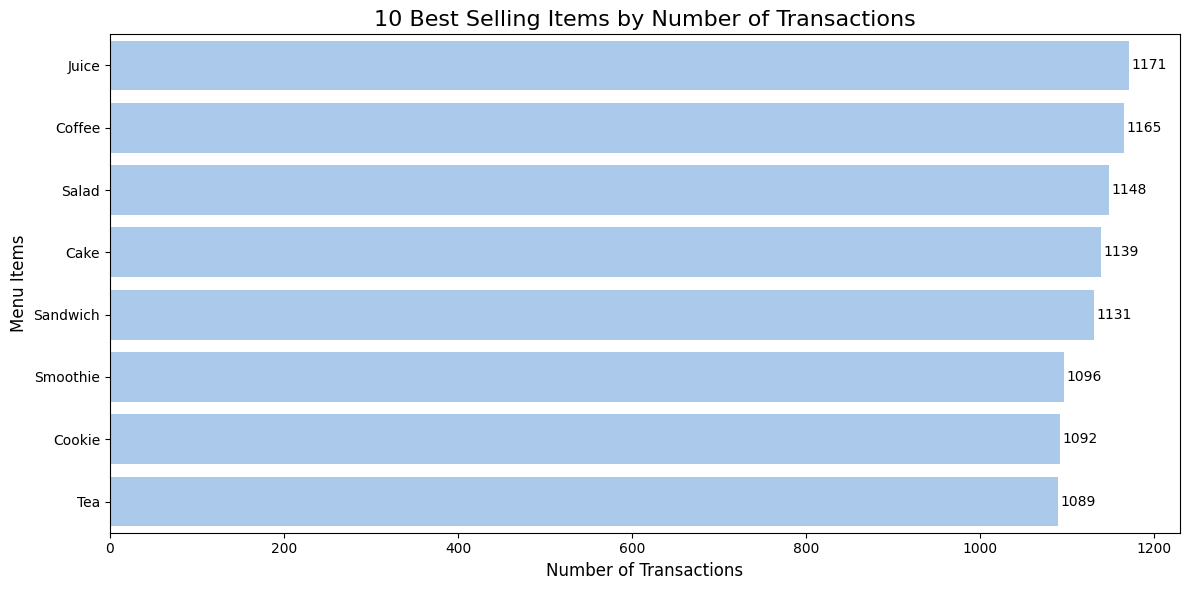

In [ ]:
plt.figure(figsize=(12, 6))
df_filtered = dataframe[dataframe['item'] != 'Unknown_Item']
plt.figure(figsize=(12, 6))
top_items = df_filtered['item'].value_counts().head(10)
ax = sns.barplot(x=top_items.values, y=top_items.index, orient='h')
plt.title('10 Best Selling Items by Number of Transactions', fontsize=16)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Menu Items', fontsize=12)

for i, v in enumerate(top_items.values):
    ax.text(v + 3, i, str(v), color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

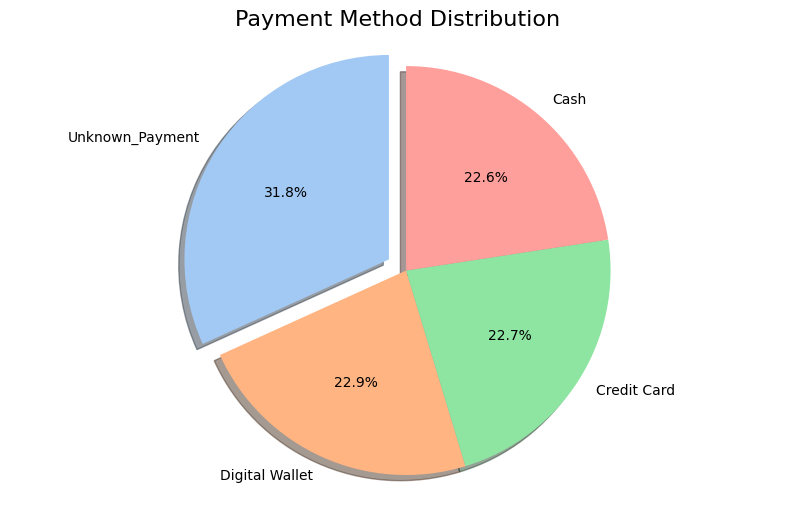

In [ ]:
plt.figure(figsize=(10, 6))
payment_counts = dataframe['payment_method'].value_counts()
explode = (0.1, 0, 0, 0)

plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%',
        startangle=90, explode=explode, shadow=True)
plt.title('Payment Method Distribution', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

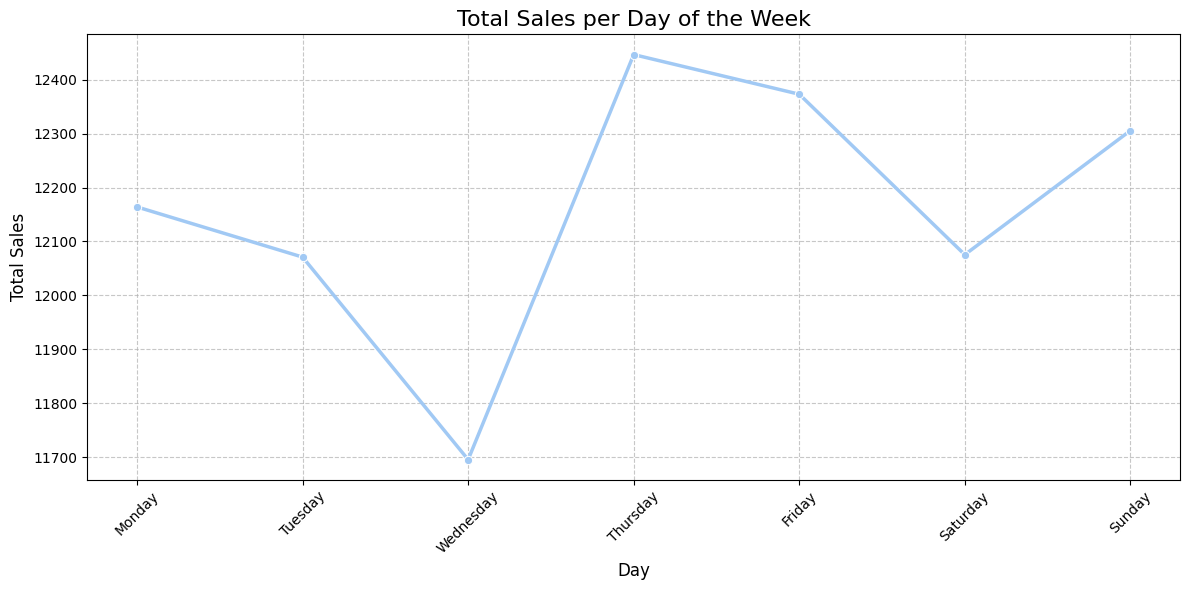

In [ ]:
# Extract days from transaction date
dataframe['day_of_week'] = dataframe['transaction_date'].dt.day_name()
dataframe['hour'] = dataframe['transaction_date'].dt.hour

plt.figure(figsize=(12, 6))
daily_sales = dataframe.groupby('day_of_week')['total_spent'].sum().reindex([
'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

sns.lineplot(x=daily_sales.index, y=daily_sales.values, marker='o', linewidth=2.5)
plt.title('Total Sales per Day of the Week', fontsize=16)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

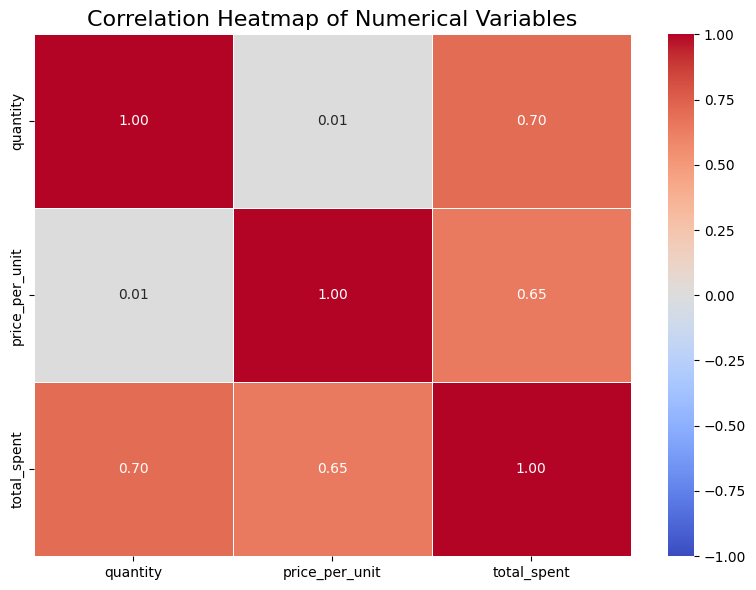

In [ ]:
plt.figure(figsize=(8, 6))
numeric_df = dataframe[['quantity', 'price_per_unit', 'total_spent']]
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2382685025.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_sales.values, y=location_sales.index, orient='h', palette='viridis')


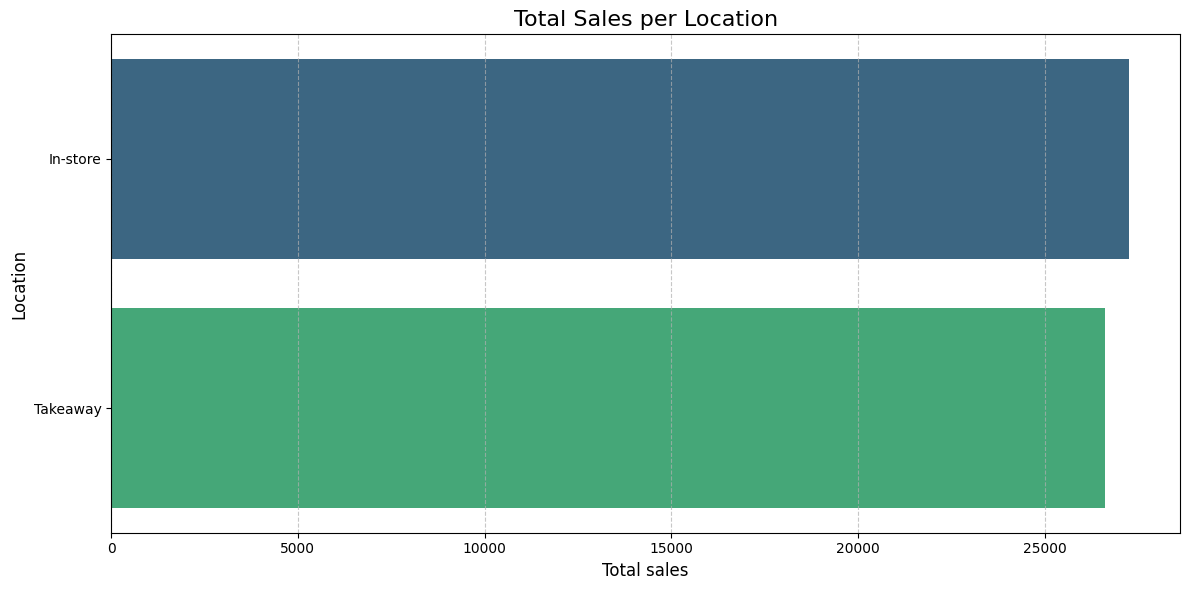

In [ ]:
plt.figure(figsize=(12, 6))
df_filtered = dataframe[dataframe['location'] != 'Unknown_Location']
location_sales = df_filtered.groupby('location')['total_spent'].sum().sort_values(ascending=False)

sns.barplot(x=location_sales.values, y=location_sales.index, orient='h', palette='viridis')
plt.title('Total Sales per Location', fontsize=16)
plt.xlabel('Total sales', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()